In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits
import healpy as hp
import yaml

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

In [5]:
tiles = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles-himalayas.fits'))
mask = tiles['SURVEY']=='sv1'
mask &= (tiles['FAPRGRM']=='lrgqso') | (tiles['FAPRGRM']=='lrgqso2')
mask &= tiles['LRG_EFFTIME_DARK']>2000.
tiles = tiles[mask]
print(len(tiles))

38


In [6]:
lrg = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_basic.fits'))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pz_new.fits', columns=['Z_PHOT_MEDIAN', 'Z_PHOT_L68', 'Z_PHOT_U68']))
lrgmask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_lrgmask_v1.1.fits.gz'))
pixel = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pixel.fits'))
lrg = hstack([lrg, pz, lrgmask, pixel], join_type='exact')
print(len(lrg))

35354635


In [7]:
target_bit = 6  # LRG_SV_IR
fn = '/global/cfs/cdirs/desi/spectro/redux/himalayas/zcatalog/ztile-sv1-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['SV1_DESI_TARGET']))
idx = np.where(cat['SV1_DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select QSO+LRG tiles
mask = np.in1d(cat['TILEID'], tiles['TILEID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select objects in the extended sample
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

# cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight', 'lrg_mask']], keys='TARGETID')
cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'Z_PHOT_MEDIAN', 'lrg_mask']], keys='TARGETID')
# cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 2000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_himalayas_20230106.txt', dtype=int)
print(len(bad_fibers))
# bad fibers identified from redshift distributions (https://github.com/desihub/desispec/issues/1946)
additional_bad_fibers = [466, 1008, 1098, 1219, 1251, 2675, 2676, 2677, 2678, 2679, 2680, 3994, 3995, 4349, 4720, 2250, 2251, 2252, 2253, 3038]
bad_fibers = np.unique(np.concatenate([bad_fibers, additional_bad_fibers]))
print(len(bad_fibers))
print(bad_fibers)
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# # Remove objects classified as STARs
# mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
# print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# exclude QSO targets
mask = ~((cat["SV1_DESI_TARGET"] & (2**2))!=0)
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]
print(len(cat))

47954 47695
42069 41968
40849 40749
40849
FIBERSTATUS    6449 34400 0.1578741217655267
No data    0 34400 0.0
LRG mask 31293 3107 0.09031976744186046
Min depth    1020 30273 0.03259514907487297
30273 30213
30213 30213
57
66
[ 466  552  651  817 1008 1098 1219 1251 1400 1597 1765 1969 2250 2251
 2252 2253 2259 2260 2261 2267 2271 2316 2575 2628 2636 2654 2663 2675
 2676 2677 2678 2679 2680 2681 2684 2685 2686 2687 2688 2689 3033 3038
 3082 3476 3500 3546 3618 3754 3849 3974 3994 3995 4002 4019 4089 4349
 4507 4613 4621 4624 4720 4733 4748 4788 4957 4977]
Bad fibers 29775 438 0.014497070797338894
NOBS 28811 964 0.9676238455079765
EBV 28132 679 0.023567387456179933
STARDENS 27407 725 0.025771363571733256
Remove QSO targets 26223 1184 0.04320064217170796
26223


In [8]:
# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()

print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]

0.007436220112115318
Quality 26028 195 0.007436220112115318


In [9]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [10]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

11230 14798


In [11]:
mask = mask_south & (cat['w1mag']>19.5)
print((cat['rmag']-cat['w1mag'])[mask].min())
mask = mask_north & (cat['w1mag']>19.5)
print((cat['rmag']-cat['w1mag'])[mask].min())

mask = mask_south.copy()
print((cat['zfibermag'])[mask].max())
mask = mask_north.copy()
print((cat['zfibermag'])[mask].max())

3.1002407
3.100193
21.999931
21.999796


In [12]:
cat_all = cat.copy()

In [13]:
cat = cat_all.copy()
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

11230 14798


In [14]:
# Adjust for North-South photometry offsets

north_sliding_cut = (cat['rmag'] - cat['w1mag'] > (cat['w1mag'] - 17.44) * 1.8)
north_sliding_cut |= ((cat['rmag']-cat['w1mag'])>3.2)
mask = mask_north & north_sliding_cut
# mask = mask_north.copy()
mask |= mask_south & (cat['zfibermag']<21.96)
print(np.sum(mask)/len(mask))
print(np.sum(mask & mask_north)/np.sum(mask_north))
print(np.sum(mask & mask_south)/np.sum(mask_south))
cat = cat[mask]
print(len(mask))

0.9507453511602889
0.9452359750667854
0.9549263413974861
26028


In [15]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

10615 14131


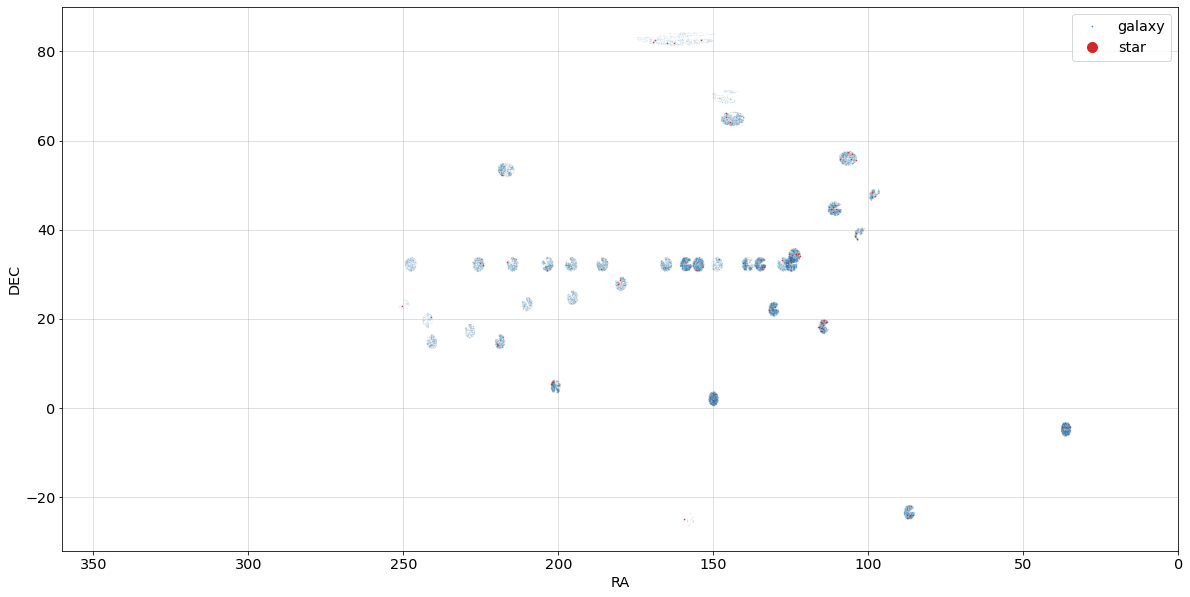

In [16]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)

plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][~mask_star], cat['DEC'][~mask_star], 'C0.', ms=.05, label='galaxy')
plt.plot(cat['RA'][mask_star], cat['DEC'][mask_star], 'C3.', ms=1, label='star')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

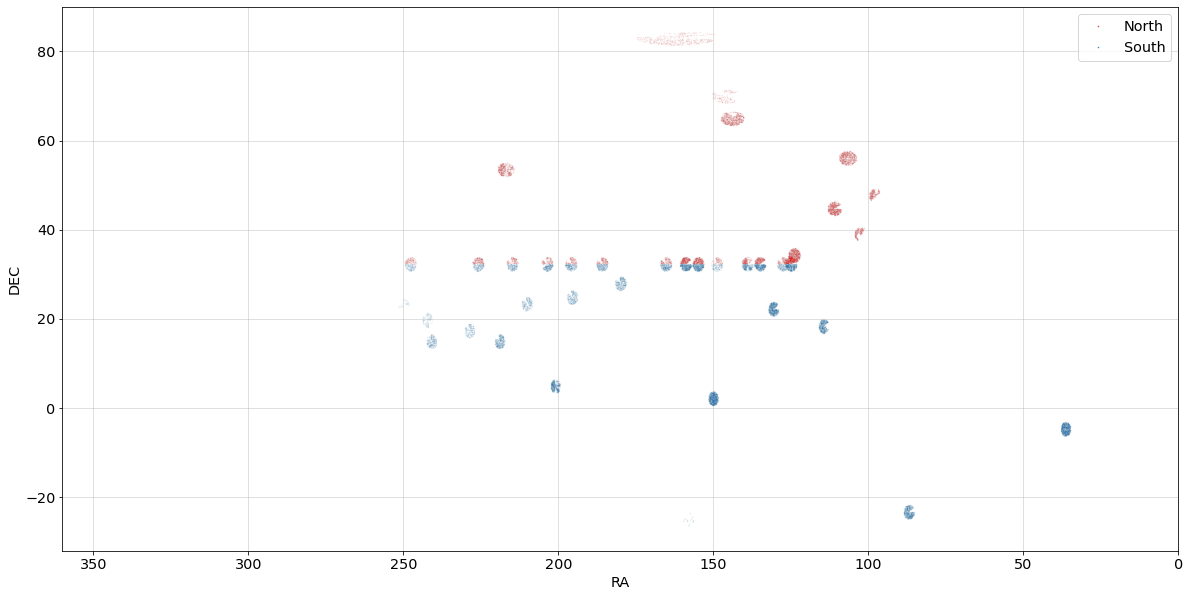

In [17]:
plt.figure(figsize=(20, 10))
plt.plot(cat['RA'][mask_north], cat['DEC'][mask_north], 'C3.', ms=.05, label='North')
plt.plot(cat['RA'][mask_south], cat['DEC'][mask_south], 'C0.', ms=.05, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.xlim(360, 0)
plt.show()

In [18]:
area = len(cat)/1800
area_south = np.sum(mask_south)/1800
area_north = np.sum(mask_north)/1800
print('{:.2f} {:.2f} {:.2f}'.format(area, area_south, area_north))

13.75 7.85 5.90


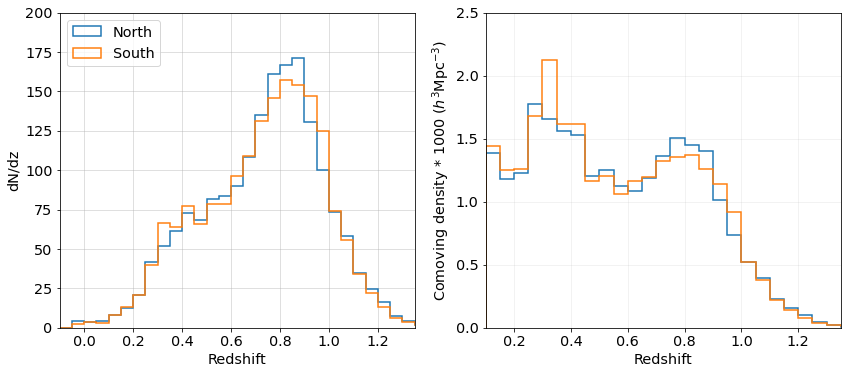

In [19]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.full(np.sum(mask_north), 1/area_north),
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.full(np.sum(mask_south), 1/area_south),
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 200)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

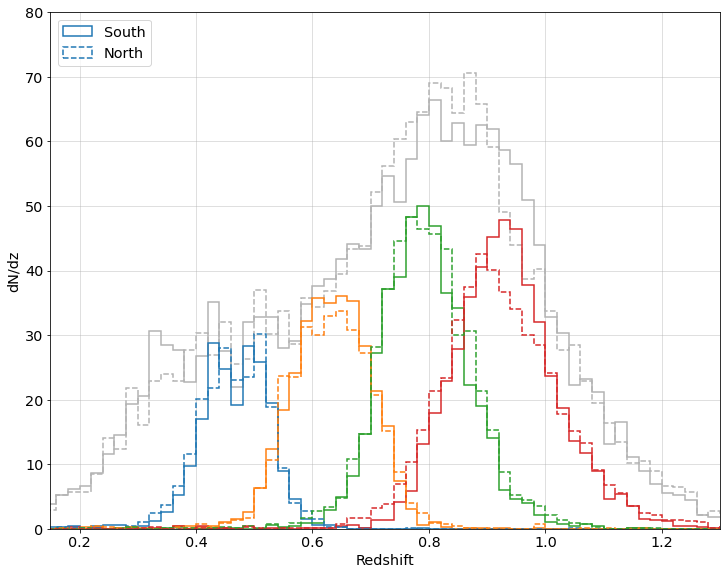

In [20]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

pz_cuts_south = [0.400, 0.540, 0.713, 0.860, 1.00]
pz_cuts_north = [0.400, 0.545, 0.719, 0.854, 1.01]

fig, ax = plt.subplots(figsize=(12, 9.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask_south), 1/area_south),
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask_north), 1/area_north),
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    pz_min, pz_max = pz_cuts_south[pz_bin-1], pz_cuts_south[pz_bin]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>=pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask), 1/area_south),
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    pz_min, pz_max = pz_cuts_north[pz_bin-1], pz_cuts_north[pz_bin]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>=pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask), 1/area_north),
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()

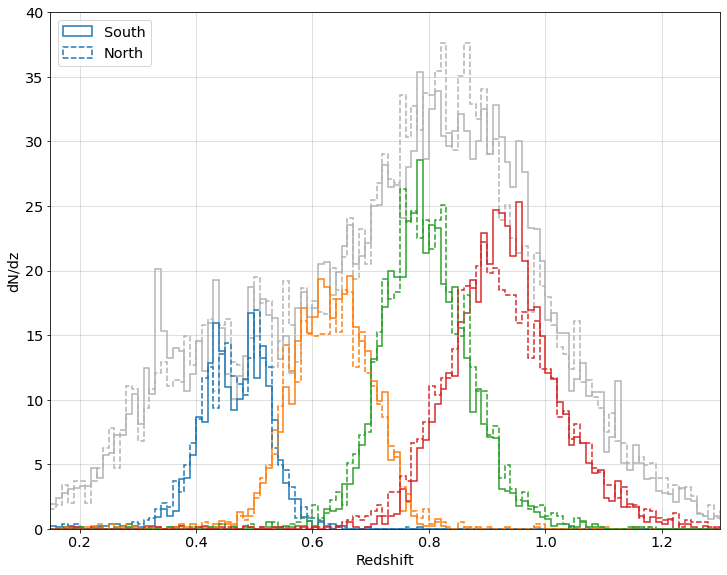

In [21]:
bins = np.arange(-0.1, 1.45, 0.01)
bin_centers = (bins[1:]+bins[:-1])/2

pz_cuts_south = [0.400, 0.540, 0.713, 0.860, 1.00]
pz_cuts_north = [0.400, 0.545, 0.719, 0.854, 1.01]

fig, ax = plt.subplots(figsize=(12, 9.5))

mask = mask_south.copy()
ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask_south), 1/area_south),
             bins=bins, lw=1.5, histtype='step', color='0.7')
mask = mask_north.copy()
ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask_north), 1/area_north),
             bins=bins, lw=1.5, histtype='step', color='0.7', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    pz_min, pz_max = pz_cuts_south[pz_bin-1], pz_cuts_south[pz_bin]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>=pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask), 1/area_south),
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    pz_min, pz_max = pz_cuts_north[pz_bin-1], pz_cuts_north[pz_bin]
    mask = mask_north & (cat['Z_PHOT_MEDIAN']>=pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    ax.hist(cat['Z'][mask], weights=np.full(np.sum(mask), 1/area_north),
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')

ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 40)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.show()